In [36]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random

In [37]:
data_root = '/astrum/home/hpchzy/code/data/'
# date_base = '20260423' # sampBase+filtOpt
date_base = '20260508' # sampOpt+filtOpt

# hostname = 'c920bn3'
# hostname = 'cgnr6760pn2'
hostname = 'camd9554n2'

output = 'output_sampOpt_filtOpt'

kernel = "jacobi2d5p"
# kernel = "tl_f90_cg_calc_w"

iarr = 1024

data_path = os.path.join(data_root, f'{date_base}/{hostname}/{output}')

freq_dict = {'camd9554n2': 3.1, 'cgnr6760pn2': 2.2, 'c920bn3': 2.9}

data_path

'/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt'

# ER EP

In [38]:
print(date_base)
print(kernel)
print(hostname)
filt_folders = glob.glob(os.path.join(data_path, f'{kernel}*n*{hostname}_filt/'))

# metric_df = pd.DataFrame(columns=['timer', 'iarr', 'er', 'ep', 'wd'])
print(filt_folders)
metric_list = []
for filt_folder in filt_folders:
    groups = re.search(f'{kernel}([0-9]+)n.*_(.*)_{hostname}_filt/', filt_folder)
    iarr = int(groups.group(1))
    timer = groups.group(2)
    with open(filt_folder + '/er.out', 'r') as f:
        er = f.read()
        f.close()
    with open(filt_folder + '/ep.out', 'r') as f:
        ep = f.read()
        f.close()
    with open(filt_folder + '/wd.out', 'r') as f:
        wd = f.read()
        f.close()
    metric_list.append({'timer': timer, 'iarr': iarr, 'er': er, 'ep': ep, 'wd': wd})

metric_df = pd.DataFrame(metric_list)
metric_df = metric_df[metric_df['timer'] != 'likwid']
metric_df.sort_values(by=['timer','iarr'], inplace=True)

result = metric_df.loc[metric_df.groupby('timer')['er'].idxmax()]
result
metric_df


20260508
jacobi2d5p
camd9554n2
['/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p512n100t_likwid_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p1024n100t_cgt_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p128n100t_tsc_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p1024n100t_papi_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p128n100t_papi_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p128n100t_cgt_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p1024n100t_tsc_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p512n100t_papi_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/

,timer,iarr,er,ep,wd
18,cgt,64,0.054715,0.001548,6.243216
5,cgt,128,0.040815,0.014288,7.988945
20,cgt,256,0.023641,0.000800,9.251256
24,cgt,512,0.455140,0.917047,712.845226
1,cgt,1024,0.137287,0.642451,1604.974874
22,papi,64,0.035326,0.000985,20.934673
4,papi,128,0.028816,0.003730,19.422111
17,papi,256,0.035817,0.000466,30.602010
7,papi,512,0.274429,0.101665,616.645226
3,papi,1024,0.312127,0.924352,3575.673367


# Filt

In [ ]:
iarr = 1024
print(iarr)
print(kernel)
print(hostname)
filt_folders = glob.glob(os.path.join(data_path, f'{kernel}{iarr}n*{hostname}_filt/'))



timer_dict = {}
print(os.path.join(data_path, f'{kernel}{iarr}n*{hostname}_filt/'))
print(filt_folders)

for filt_folder in filt_folders:
    timer = re.search(f'{kernel}{iarr}n.*_(.*)_{hostname}_filt/', filt_folder).group(1)
    print(filt_folder)
    if timer == 'likwid':
        continue
    
    tm_hist_path = os.path.join(filt_folder, 'tm_hist.csv')
    tm_hist_df = pd.read_csv(tm_hist_path, header=None)
    tm_hist_df.columns = ['ns', 'pr']
    tm_hist_df['ns'] = pd.to_numeric(tm_hist_df['ns'], errors='coerce')
    tm_hist_df['pr'] = pd.to_numeric(tm_hist_df['pr'], errors='coerce')
    tm_hist_df = (
        tm_hist_df.dropna(subset=['ns', 'pr'])
        .loc[lambda d: d['pr'] > 0.0]
        .sort_values('ns', kind='stable')
        .reset_index(drop=True)
    )

    tr_hist_path = os.path.join(filt_folder, 'tr_hist.csv')
    tr_hist_df = pd.read_csv(tr_hist_path, header=None)
    tr_hist_df.columns = ['ns', 'pr']
    tr_hist_df['ns'] = pd.to_numeric(tr_hist_df['ns'], errors='coerce')
    tr_hist_df['pr'] = pd.to_numeric(tr_hist_df['pr'], errors='coerce')
    tr_hist_df = (
        tr_hist_df.dropna(subset=['ns', 'pr'])
        .loc[lambda d: d['pr'] > 0.0]
        .sort_values('ns', kind='stable')
        .reset_index(drop=True)
    )

    tm_cdf_df = tm_hist_df.assign(cdf=tm_hist_df['pr'].cumsum())
    tr_cdf_df = tr_hist_df.assign(cdf=tr_hist_df['pr'].cumsum())

    timer_dict[timer] = {
        'tm_cdf_df': tm_cdf_df,
        'tr_cdf_df': tr_cdf_df
    }

    # fig, ax = pyplot.subplots(figsize=(10, 5))
    # ax.plot(tm_cdf_df['ns'], tm_cdf_df['cdf'], label='tm_cdf')
    # ax.plot(tr_cdf_df['ns'], tr_cdf_df['cdf'], label='tr_cdf')
    # ax.set_xlabel('ns')
    # ax.set_ylabel('cdf')
    # ax.set_title(timer)
    # ax.grid(True, alpha=0.3)
    # ax.legend()

    # print(tm_hist_df.head())
    # print(tr_hist_df.tail())


/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p1024n*camd9554n2_filt/
['/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p1024n100t_cgt_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p1024n100t_papi_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p1024n100t_tsc_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p1024n100t_likwid_camd9554n2_filt/', '/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p1024n100t_papix6_camd9554n2_filt/']
/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p1024n100t_cgt_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt/jacobi2d5p1024n100t_papi_camd9554n2_filt/
/astrum/home/hpchzy/code/data/20260508/camd9554n2/output_sampOpt_filtOpt

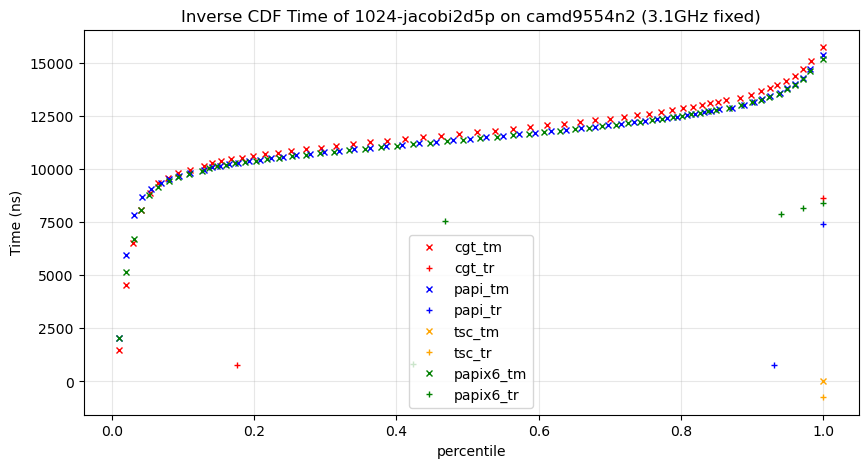

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
color_list = ['red', 'blue', 'orange', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'lime', 'teal', 'navy', 'maroon', 'gold', 'silver', 'indigo', 'turquoise', 'coral']
for i, timer in enumerate(timer_dict.keys()):
    if timer in ['likwid']:
        continue
    # if timer not in ['tsc']:
    #     continue

    ax.plot(timer_dict[timer]['tm_cdf_df']['cdf'], timer_dict[timer]['tm_cdf_df']['ns'], label=f'{timer}_tm', color=color_list[i], linestyle='None', marker='x', markersize=5)
    ax.plot(timer_dict[timer]['tr_cdf_df']['cdf'], timer_dict[timer]['tr_cdf_df']['ns'], label=f'{timer}_tr', color=color_list[i], linestyle='None', marker='+', markersize=5)

ax.set_xlabel('percentile')
ax.set_ylabel('Time (ns)')
ax.set_title(f'Inverse CDF Time of {iarr}-{kernel} on {hostname} ({freq_dict[hostname]}GHz fixed)')
ax.grid(True, alpha=0.3)

ax.legend()